# Problema de Transporte — Modelo Extendido con Análisis de Sensibilidad

**Programación Matemática · Semestre 1**

---

## Formulación

$$
\min \quad \sum_{i \in I} \sum_{j \in J} c_{ij} \, x_{ij}
$$

$$
\text{s.t.} \quad \sum_{j \in J} x_{ij} \leq s_i \quad \forall i \in I \quad \text{(oferta)}
$$

$$
\quad \sum_{i \in I} x_{ij} = d_j \quad \forall j \in J \quad \text{(demanda)}
$$

$$
\quad 0 \leq x_{ij} \leq u_{ij} \quad \forall i \in I,\, j \in J \quad \text{(capacidad de ruta)}
$$

**Instancia**: 6 plantas de origen · 8 centros de distribución · 48 rutas · capacidades individuales por arco

In [1]:
import gurobipy as gb
from gurobipy import GRB, quicksum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Estilo global de gráficos
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.family": "monospace",
})
PALETTE = {"planta": "#4C72B0", "cd": "#DD8452", "activo": "#2ca02c", "inactivo": "#d62728", "neutro": "#7f7f7f"}

## 1. Datos sintéticos

Instancia con **6 plantas** y **8 centros de distribución** (1 050 unidades totales, problema balanceado).  
Se agregan **capacidades por ruta** `u[i,j]` para aumentar la complejidad del espacio factible.

In [2]:
# --- Conjuntos ---
I = ["Planta_A", "Planta_B", "Planta_C", "Planta_D", "Planta_E", "Planta_F"]
J = ["CD_01", "CD_02", "CD_03", "CD_04", "CD_05", "CD_06", "CD_07", "CD_08"]

# --- Oferta [u] --- (total = 1 050)
s = {"Planta_A": 200, "Planta_B": 180, "Planta_C": 150,
     "Planta_D": 220, "Planta_E": 170, "Planta_F": 130}

# --- Demanda [u] --- (total = 1 050, balanceado)
d = {"CD_01": 120, "CD_02": 160, "CD_03": 140, "CD_04": 180,
     "CD_05": 100, "CD_06": 150, "CD_07": 120, "CD_08": 80}

assert sum(s.values()) == sum(d.values()), "Problema desbalanceado"

# --- Costo unitario de transporte c[i,j] [$/u] ---
cost_matrix = np.array([
#  CD01  CD02  CD03  CD04  CD05  CD06  CD07  CD08
  [  2,    8,   12,   15,    6,   10,   14,   18],  # Planta_A
  [  9,    3,    7,   11,   13,    5,    9,   16],  # Planta_B
  [ 14,    6,    2,    8,   17,    4,    7,   12],  # Planta_C
  [ 11,   13,    9,    3,    8,   15,    6,    5],  # Planta_D
  [  7,   10,   15,    6,    2,   11,   13,    9],  # Planta_E
  [ 16,    5,   11,    9,   14,    2,    8,    3],  # Planta_F
])
c = {(I[i], J[j]): cost_matrix[i, j] for i in range(len(I)) for j in range(len(J))}

# --- Capacidad de ruta u[i,j] [u] ---
# Restricción activa en rutas clave para aumentar complejidad del modelo
cap_matrix = np.array([
#  CD01  CD02  CD03  CD04  CD05  CD06  CD07  CD08
  [ 120,   80,   60,   50,  100,   70,   40,   30],  # Planta_A
  [  60,  120,   90,   80,   50,  110,   70,   40],  # Planta_B
  [  50,   80,  120,   90,   40,  100,   80,   60],  # Planta_C
  [  80,   60,   70,  150,   90,   50,  110,  100],  # Planta_D
  [ 100,   70,   50,   80,  120,   60,   50,   90],  # Planta_E
  [  40,  110,   80,   70,   60,  130,   90,  100],  # Planta_F
])
u = {(I[i], J[j]): cap_matrix[i, j] for i in range(len(I)) for j in range(len(J))}

print(f"Plantas : {len(I)}  |  CDs : {len(J)}  |  Rutas : {len(I)*len(J)}")
print(f"Oferta total  : {sum(s.values()):,} u.")
print(f"Demanda total : {sum(d.values()):,} u.")

Plantas : 6  |  CDs : 8  |  Rutas : 48
Oferta total  : 1,050 u.
Demanda total : 1,050 u.


## 2. Visualización de datos — Matriz de costos y capacidades

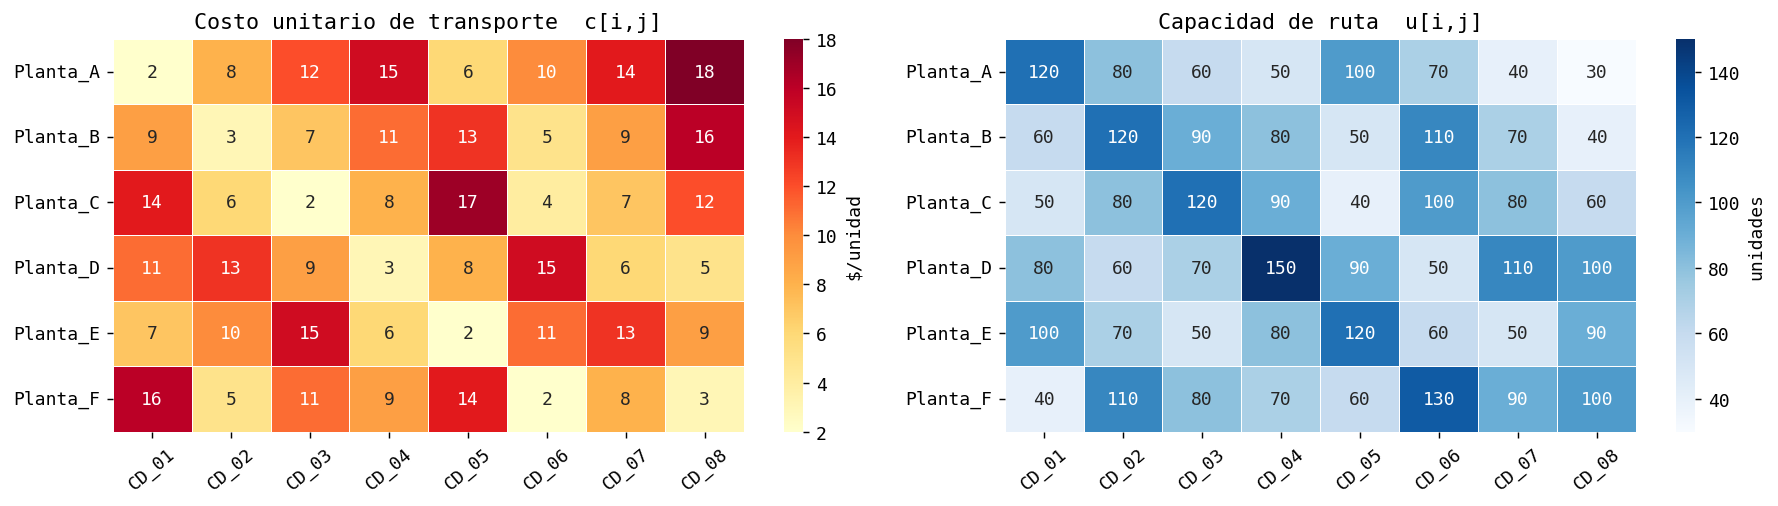

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap de costos
sns.heatmap(cost_matrix, ax=axes[0], annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=J, yticklabels=I, linewidths=0.5, cbar_kws={"label": "$/unidad"})
axes[0].set_title("Costo unitario de transporte  c[i,j]")
axes[0].tick_params(axis="x", rotation=40)

# Heatmap de capacidades
sns.heatmap(cap_matrix, ax=axes[1], annot=True, fmt="d", cmap="Blues",
            xticklabels=J, yticklabels=I, linewidths=0.5, cbar_kws={"label": "unidades"})
axes[1].set_title("Capacidad de ruta  u[i,j]")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()

## 3. Modelo Gurobi

In [4]:
m = gb.Model("transporte_extendido")
#m.setParam("OutputFlag", 0)

# Variables: x[i,j] con ub individual por ruta
X = m.addVars(
    [(i, j) for i in I for j in J],
    vtype=GRB.CONTINUOUS,
    lb=0,
    ub={k: u[k] for k in [(i, j) for i in I for j in J]},
    name="x",
)

# Función objetivo
m.setObjective(quicksum(c[i, j] * X[i, j] for i in I for j in J), GRB.MINIMIZE)

# Restricciones de oferta
c_oferta = m.addConstrs(
    (quicksum(X[i, j] for j in J) <= s[i] for i in I), name="oferta"
)

# Restricciones de demanda
c_demanda = m.addConstrs(
    (quicksum(X[i, j] for i in I) == d[j] for j in J), name="demanda"
)

m.optimize()

status_str = {GRB.OPTIMAL: "ÓPTIMO", GRB.INFEASIBLE: "INFACTIBLE", GRB.UNBOUNDED: "NO ACOTADO"}
print(f"Estado : {status_str.get(m.Status, m.Status)}")
print(f"Costo total mínimo : ${m.ObjVal:,.2f}")
print(f"Variables          : {m.NumVars}  |  Restricciones : {m.NumConstrs}")

Set parameter Username
Set parameter LicenseID to value 2811969
Academic license - for non-commercial use only - expires 2027-04-22
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 14 rows, 48 columns and 96 nonzeros
Model fingerprint: 0x4262002c
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+00, 2e+01]
  Bounds range     [3e+01, 2e+02]
  RHS range        [8e+01, 2e+02]
Presolve time: 0.00s
Presolved: 14 rows, 48 columns, 96 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.0000000e+03   3.750000e+01   0.000000e+00      0s
      12    4.0000000e+03   0.000000e+00   0.000000e+00      0s

Solved in 12 iterations and 0.01 seconds (0.00 work units)
Optimal objective  4.000000000e+03
Estado : ÓPTIMO
Costo total mínimo : $4,000.00
Variables          : 48  |  Restri

## 4. Solución óptima

In [5]:
# Tabla de rutas activas
flujos = [
    {"Origen": i, "Destino": j,
     "Flujo": X[i, j].X,
     "Capacidad": u[i, j],
     "Uso (%)": 100 * X[i, j].X / u[i, j],
     "c[i,j]": c[i, j],
     "Costo total": c[i, j] * X[i, j].X}
    for i in I for j in J if X[i, j].X > 1e-6
]
df_sol = pd.DataFrame(flujos).sort_values("Costo total", ascending=False)

# Matriz de flujos
sol_matrix = np.array([[X[i, j].X for j in J] for i in I])
df_matriz = pd.DataFrame(sol_matrix, index=I, columns=J)

print(f"Rutas activas: {len(df_sol)} de {len(I)*len(J)}\n")
display(df_sol.style.format({"Flujo": "{:.1f}", "Uso (%)": "{:.1f}%", "Costo total": "${:.1f}"})
        .background_gradient(subset=["Uso (%)"], cmap="Oranges")
        .background_gradient(subset=["Costo total"], cmap="Reds"))
print("\nMatriz de flujos:")
display(df_matriz.style.format("{:.0f}").background_gradient(cmap="Greens"))

Rutas activas: 15 de 48



,Origen,Destino,Flujo,Capacidad,Uso (%),"c[i,j]",Costo total
10,Planta_D,CD_07,110.0,110,100.0%,6,$660.0
11,Planta_E,CD_04,70.0,80,87.5%,6,$420.0
4,Planta_B,CD_02,120.0,120,100.0%,3,$360.0
9,Planta_D,CD_04,110.0,150,73.3%,3,$330.0
1,Planta_A,CD_02,40.0,80,50.0%,8,$320.0
5,Planta_B,CD_06,60.0,110,54.5%,5,$300.0
0,Planta_A,CD_01,120.0,120,100.0%,2,$240.0
2,Planta_A,CD_03,20.0,60,33.3%,12,$240.0
6,Planta_C,CD_03,120.0,120,100.0%,2,$240.0
14,Planta_F,CD_08,80.0,100,80.0%,3,$240.0



Matriz de flujos:


,CD_01,CD_02,CD_03,CD_04,CD_05,CD_06,CD_07,CD_08
Planta_A,120,40,20,0,0,20,0,0
Planta_B,0,120,0,0,0,60,0,0
Planta_C,0,0,120,0,0,20,10,0
Planta_D,0,0,0,110,0,0,110,0
Planta_E,0,0,0,70,100,0,0,0
Planta_F,0,0,0,0,0,50,0,80


## 5. Visualización de la solución

### 5a — Red de flujos (grafo bipartito)

/var/folders/lv/7jjr9j3j6_z3rvw5vz220g3m0000gn/T/ipykernel_41808/2755752784.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_edge = plt.cm.get_cmap("Blues")


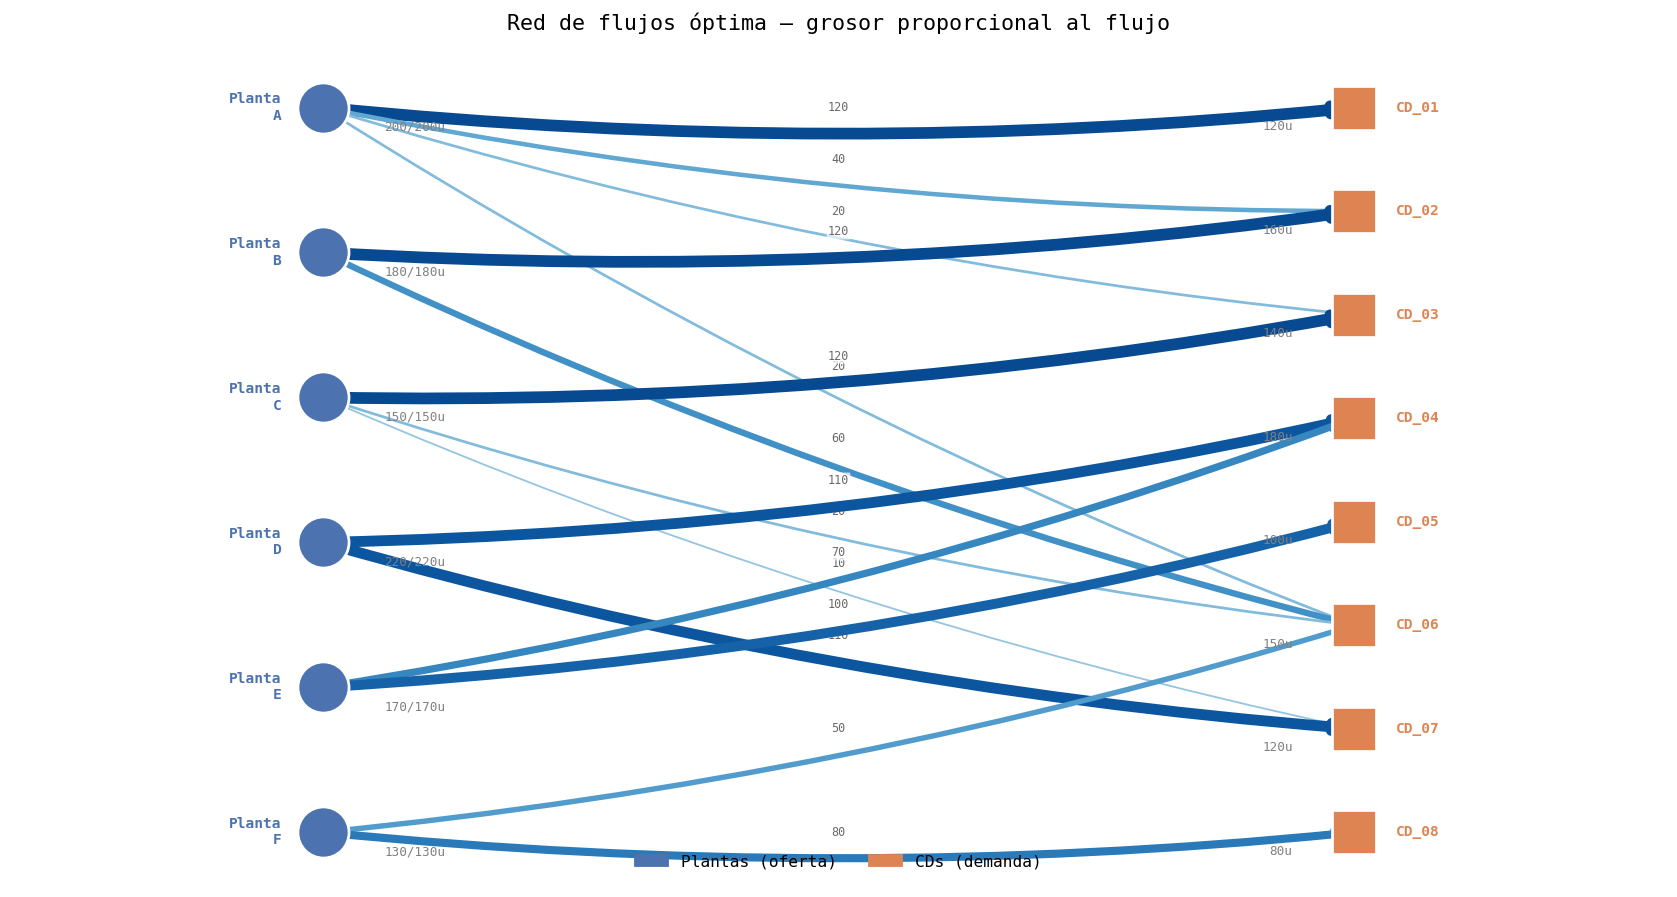

In [6]:
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.5, max(len(I), len(J)) - 0.5)
ax.axis("off")
ax.set_title("Red de flujos óptima — grosor proporcional al flujo", pad=14)

# Posiciones de nodos
pos_i = {i: (0.0, (len(I) - 1 - idx) * (len(J) - 1) / (len(I) - 1)) for idx, i in enumerate(I)}
pos_j = {j: (1.0, (len(J) - 1 - idx) * 1.0) for idx, j in enumerate(J)}

max_flow = max(X[i, j].X for i in I for j in J)
cmap_edge = plt.cm.get_cmap("Blues")

# Arcos activos
for i in I:
    for j in J:
        flow = X[i, j].X
        if flow < 1e-6:
            continue
        xi, yi = pos_i[i]
        xj, yj = pos_j[j]
        lw = 0.5 + 6 * flow / max_flow
        color = cmap_edge(0.35 + 0.55 * flow / max_flow)
        ax.annotate("", xy=(xj, yj), xytext=(xi, yi),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                                   connectionstyle="arc3,rad=0.05"))
        mx, my = (xi + xj) / 2, (yi + yj) / 2
        ax.text(mx, my, f"{flow:.0f}", fontsize=6.5, ha="center", va="center",
                color="dimgray", bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.7))

# Nodos de plantas
for i, (xi, yi) in pos_i.items():
    used = sum(X[i, j].X for j in J)
    ax.scatter(xi, yi, s=800, color=PALETTE["planta"], zorder=5, edgecolors="white", linewidths=1.5)
    ax.text(xi - 0.04, yi, i.replace("_", "\n"), fontsize=8, ha="right", va="center",
            color=PALETTE["planta"], fontweight="bold")
    ax.text(xi + 0.06, yi - 0.22, f"{used:.0f}/{s[i]}u", fontsize=7, ha="left", color="gray")

# Nodos de CDs
for j, (xj, yj) in pos_j.items():
    ax.scatter(xj, yj, s=600, color=PALETTE["cd"], marker="s", zorder=5,
               edgecolors="white", linewidths=1.5)
    ax.text(xj + 0.04, yj, j, fontsize=8, ha="left", va="center",
            color=PALETTE["cd"], fontweight="bold")
    ax.text(xj - 0.06, yj - 0.22, f"{d[j]}u", fontsize=7, ha="right", color="gray")

# Leyenda
p1 = mpatches.Patch(color=PALETTE["planta"], label="Plantas (oferta)")
p2 = mpatches.Patch(color=PALETTE["cd"],     label="CDs (demanda)")
ax.legend(handles=[p1, p2], loc="lower center", ncol=2, frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### 5b — Heatmap de flujos y uso de capacidad

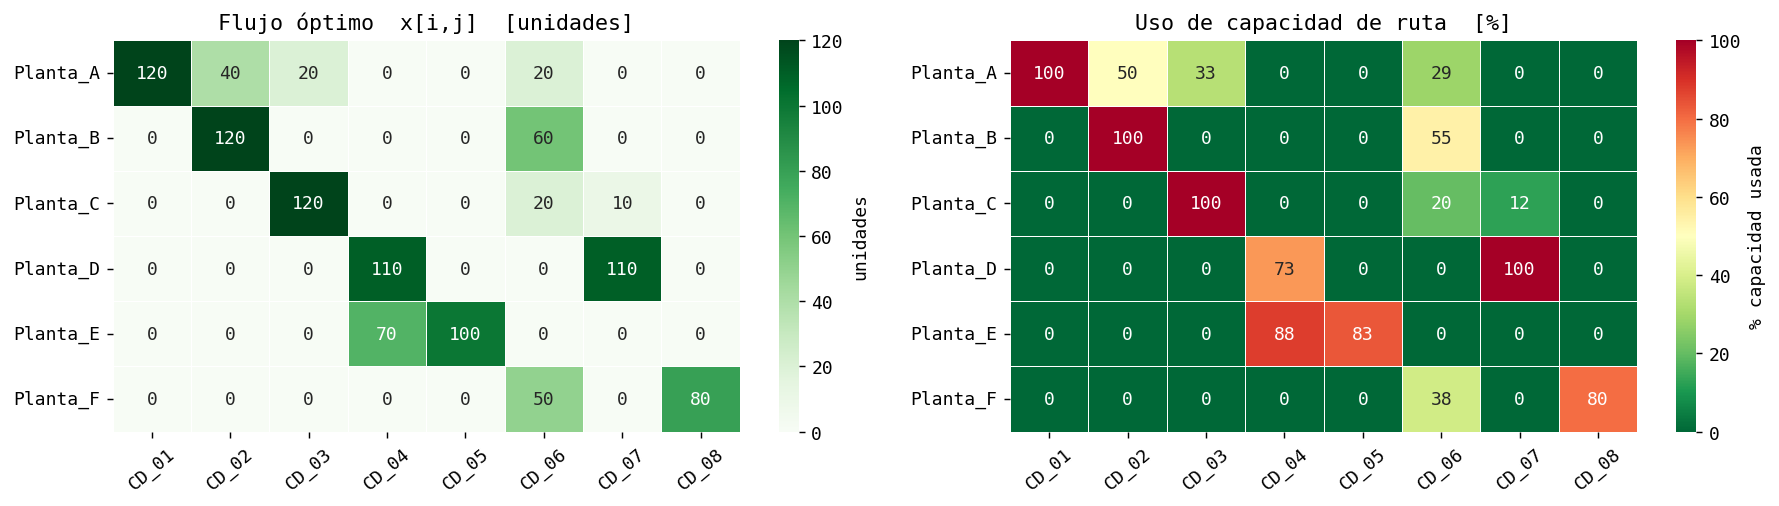

In [7]:
uso_matrix = np.array([[100 * X[i, j].X / u[i, j] for j in J] for i in I])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(sol_matrix, ax=axes[0], annot=True, fmt=".0f", cmap="Greens",
            xticklabels=J, yticklabels=I, linewidths=0.5, cbar_kws={"label": "unidades"})
axes[0].set_title("Flujo óptimo  x[i,j]  [unidades]")
axes[0].tick_params(axis="x", rotation=40)

sns.heatmap(uso_matrix, ax=axes[1], annot=True, fmt=".0f", cmap="RdYlGn_r",
            xticklabels=J, yticklabels=I, linewidths=0.5,
            vmin=0, vmax=100, cbar_kws={"label": "% capacidad usada"})
axes[1].set_title("Uso de capacidad de ruta  [%]")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()

## 6. Análisis de sensibilidad — Restricciones

### Conceptos clave
| Indicador | Símbolo | Interpretación |
|---|---|---|
| **Precio sombra** | π | Cambio en el costo óptimo por cada unidad adicional de RHS |
| **Holgura** | slack | Capacidad de oferta no utilizada (solo en ≤) |
| **Rango RHS** | [RHS↓, RHS↑] | Intervalo en que π se mantiene constante (base no cambia) |

In [8]:
rows = []
for i in I:
    ct = c_oferta[i]
    rows.append({"Nombre": f"oferta_{i}", "Tipo": "Oferta (≤)", "RHS": s[i],
                 "Holgura": ct.Slack, "Pi": ct.Pi,
                 "RHS_low": ct.SARHSLow, "RHS_up": ct.SARHSUp})
for j in J:
    ct = c_demanda[j]
    rows.append({"Nombre": f"demanda_{j}", "Tipo": "Demanda (=)", "RHS": d[j],
                 "Holgura": ct.Slack, "Pi": ct.Pi,
                 "RHS_low": ct.SARHSLow, "RHS_up": ct.SARHSUp})

df_c = pd.DataFrame(rows)
display(df_c.style
        .format({"Holgura": "{:.1f}", "Pi": "{:.3f}", "RHS_low": "{:.1f}", "RHS_up": "{:.1f}"})
        .background_gradient(subset=["Pi"], cmap="coolwarm", vmin=-15, vmax=15)
        .background_gradient(subset=["Holgura"], cmap="Greens"))

,Nombre,Tipo,RHS,Holgura,Pi,RHS_low,RHS_up
0,oferta_Planta_A,Oferta (≤),200,0.0,0.000,200.0,inf
1,oferta_Planta_B,Oferta (≤),180,0.0,-5.000,180.0,200.0
2,oferta_Planta_C,Oferta (≤),150,0.0,-6.000,150.0,170.0
3,oferta_Planta_D,Oferta (≤),220,0.0,-6.000,220.0,240.0
4,oferta_Planta_E,Oferta (≤),170,0.0,-3.000,170.0,180.0
5,oferta_Planta_F,Oferta (≤),130,0.0,-8.000,130.0,150.0
6,demanda_CD_01,Demanda (=),120,0.0,2.000,0.0,120.0
7,demanda_CD_02,Demanda (=),160,0.0,8.000,120.0,160.0
8,demanda_CD_03,Demanda (=),140,0.0,12.000,120.0,140.0
9,demanda_CD_04,Demanda (=),180,0.0,9.000,160.0,180.0


### 6a — Precios sombra (π) por restricción

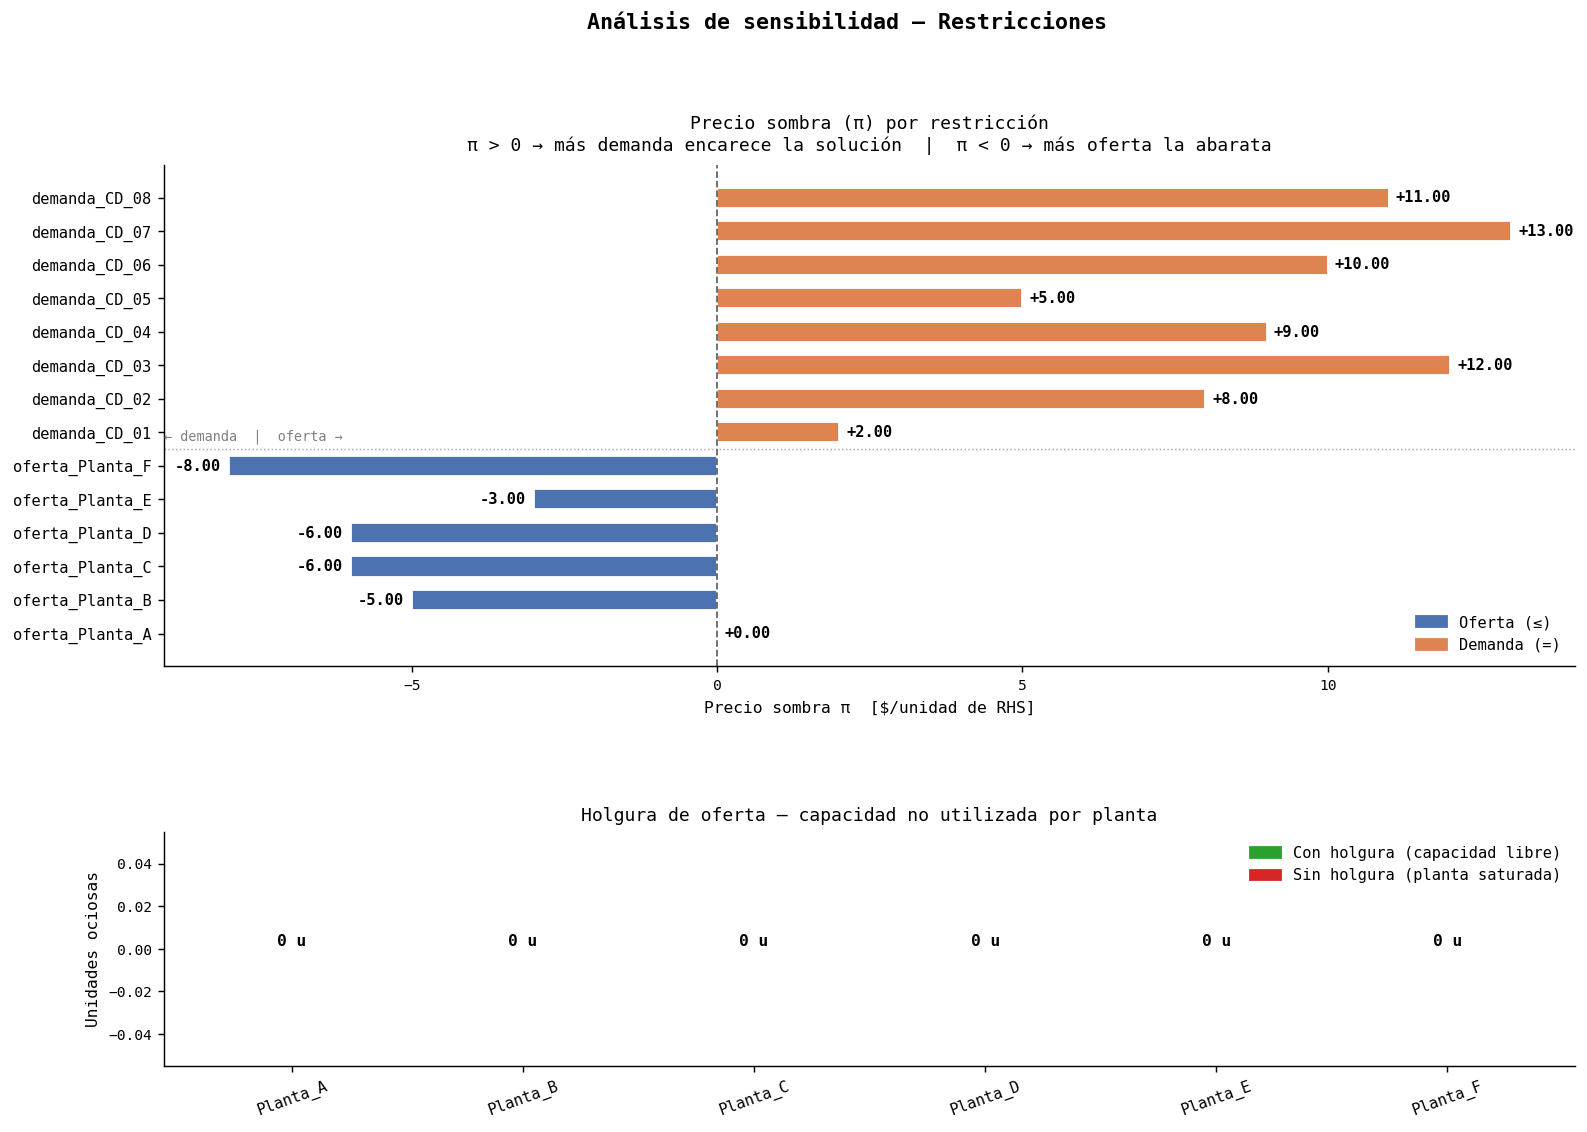

In [9]:
fig = plt.figure(figsize=(14, 9))
gs  = GridSpec(2, 2, figure=fig, height_ratios=[3, 1.4], hspace=0.45, wspace=0.35)

ax_pi    = fig.add_subplot(gs[0, :])   # precio sombra — fila completa, alto
ax_slack = fig.add_subplot(gs[1, :])   # holgura de oferta — fila completa, bajo

# ── Precio sombra (π) ──────────────────────────────────────────────────────
labels = df_c["Nombre"].tolist()
pi_vals = df_c["Pi"].tolist()
colors  = [PALETTE["planta"] if "oferta" in n else PALETTE["cd"] for n in labels]

bars = ax_pi.barh(labels, pi_vals, color=colors, edgecolor="white", height=0.6)
ax_pi.axvline(0, color="black", lw=1, ls="--", alpha=0.6)

# Línea separadora entre grupo oferta y grupo demanda
sep_y = len(I) - 0.5
ax_pi.axhline(sep_y, color="gray", lw=0.8, ls=":", alpha=0.7)
ax_pi.text(ax_pi.get_xlim()[0] if pi_vals else -1, sep_y + 0.15,
           "← demanda  |  oferta →", fontsize=7.5, color="gray", va="bottom")

# Etiquetas de valor dentro/fuera de la barra
for bar, val in zip(bars, pi_vals):
    pad   = 0.12
    xpos  = val + pad if val >= 0 else val - pad
    align = "left"    if val >= 0 else "right"
    ax_pi.text(xpos, bar.get_y() + bar.get_height() / 2,
               f"{val:+.2f}", va="center", ha=align, fontsize=8.5,
               color="black", fontweight="bold")

ax_pi.set_xlabel("Precio sombra π  [$/unidad de RHS]", fontsize=9)
ax_pi.set_title("Precio sombra (π) por restricción\n"
                "π > 0 → más demanda encarece la solución  |  π < 0 → más oferta la abarata",
                pad=8, fontsize=10)
ax_pi.tick_params(axis="y", labelsize=8.5)
ax_pi.tick_params(axis="x", labelsize=8)

p1 = mpatches.Patch(color=PALETTE["planta"], label="Oferta (≤)")
p2 = mpatches.Patch(color=PALETTE["cd"],     label="Demanda (=)")
ax_pi.legend(handles=[p1, p2], frameon=False, fontsize=8.5, loc="lower right")

# ── Holgura de oferta ──────────────────────────────────────────────────────
df_oferta  = df_c[df_c["Tipo"] == "Oferta (≤)"].copy()
plant_names = df_oferta["Nombre"].str.replace("oferta_", "", regex=False).tolist()
slacks      = df_oferta["Holgura"].tolist()
slack_colors = [PALETTE["activo"] if v > 0 else PALETTE["inactivo"] for v in slacks]

bar2 = ax_slack.bar(plant_names, slacks, color=slack_colors, edgecolor="white", width=0.55)
ax_slack.set_ylabel("Unidades ociosas", fontsize=9)
ax_slack.set_title("Holgura de oferta — capacidad no utilizada por planta", fontsize=10)
ax_slack.tick_params(axis="x", rotation=20, labelsize=8.5)
ax_slack.tick_params(axis="y", labelsize=8)

for b, v in zip(bar2, slacks):
    ypos = v + max(slacks) * 0.02 if v >= 0 else -max(slacks) * 0.04
    ax_slack.text(b.get_x() + b.get_width() / 2, ypos,
                  f"{v:.0f} u", ha="center", va="bottom", fontsize=9, fontweight="bold")

p3 = mpatches.Patch(color=PALETTE["activo"],   label="Con holgura (capacidad libre)")
p4 = mpatches.Patch(color=PALETTE["inactivo"], label="Sin holgura (planta saturada)")
ax_slack.legend(handles=[p3, p4], frameon=False, fontsize=8.5)

plt.suptitle("Análisis de sensibilidad — Restricciones", fontsize=12, fontweight="bold", y=1.01)
plt.show()

### 6b — Rango RHS (tornado chart)

Cada barra muestra el intervalo `[RHS↓, RHS↑]` en que el precio sombra π **permanece constante**.  
El punto central es el valor actual del RHS. Una barra angosta indica una restricción **muy sensible**.

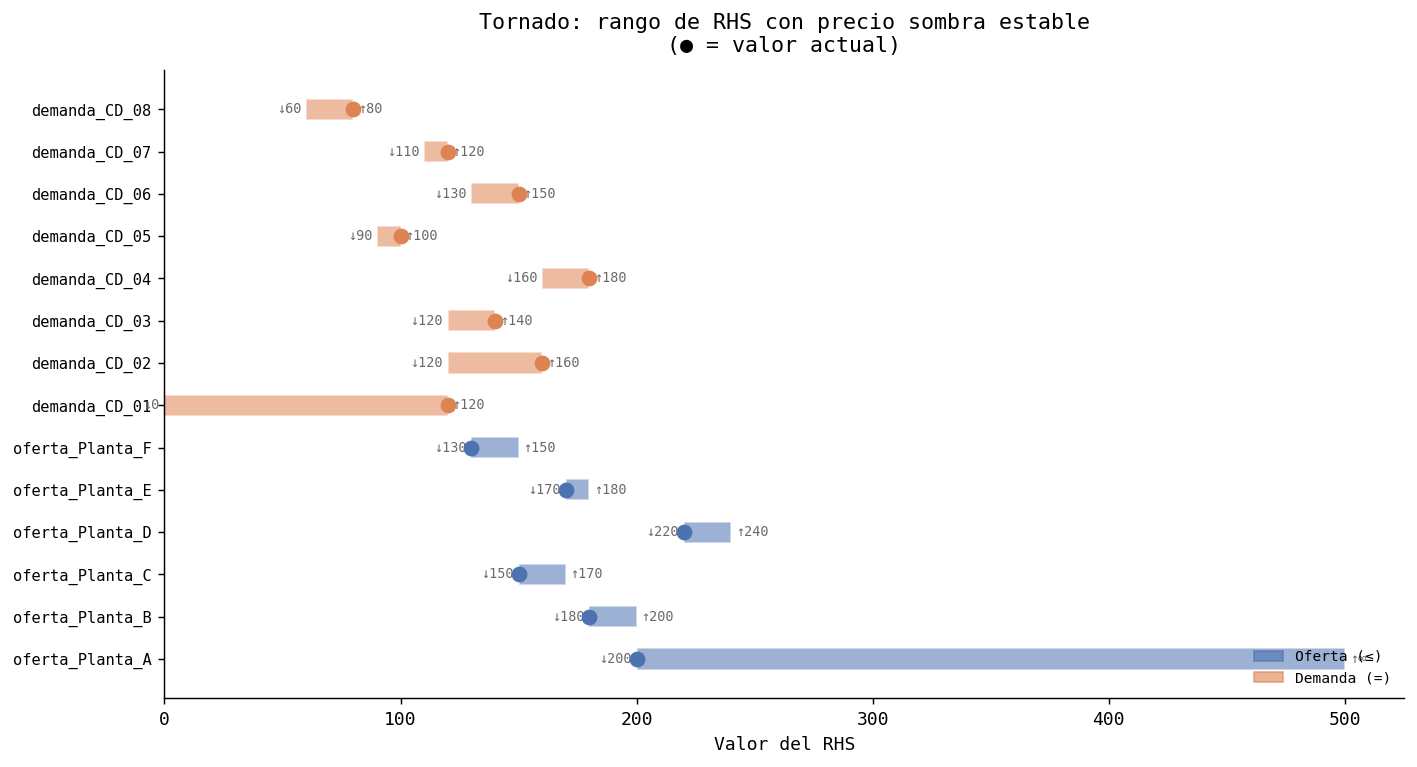

In [10]:
df_tornado = df_c.copy()
# Clampar infinitos para graficar
INF_CLAMP = 500
df_tornado["RHS_low_c"] = df_tornado["RHS_low"].clip(lower=-INF_CLAMP)
df_tornado["RHS_up_c"]  = df_tornado["RHS_up"].clip(upper=INF_CLAMP)

fig, ax = plt.subplots(figsize=(11, 6))
labels  = df_tornado["Nombre"].tolist()
y_pos   = np.arange(len(labels))
colors  = [PALETTE["planta"] if "oferta" in n else PALETTE["cd"] for n in labels]

for idx, row in df_tornado.iterrows():
    yi = list(df_tornado["Nombre"]).index(row["Nombre"])
    lo, hi, cur = row["RHS_low_c"], row["RHS_up_c"], row["RHS"]
    ax.barh(yi, hi - lo, left=lo, height=0.5, color=colors[yi], alpha=0.55, edgecolor="white")
    ax.scatter(cur, yi, color=colors[yi], zorder=5, s=60)
    ax.text(hi + 2, yi, f"↑{row['RHS_up']:.0f}" if row["RHS_up"] < INF_CLAMP else "↑∞",
            va="center", fontsize=7.5, color="dimgray")
    ax.text(lo - 2, yi, f"↓{row['RHS_low']:.0f}" if row["RHS_low"] > -INF_CLAMP else "↓∞",
            va="center", ha="right", fontsize=7.5, color="dimgray")

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xlabel("Valor del RHS")
ax.set_title("Tornado: rango de RHS con precio sombra estable\n(● = valor actual)", pad=10)
ax.axvline(0, color="black", lw=0.6, ls=":")

p1 = mpatches.Patch(color=PALETTE["planta"], alpha=0.6, label="Oferta (≤)")
p2 = mpatches.Patch(color=PALETTE["cd"],     alpha=0.6, label="Demanda (=)")
ax.legend(handles=[p1, p2], frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 7. Análisis de sensibilidad — Variables

### Conceptos clave
| Indicador | Símbolo | Interpretación |
|---|---|---|
| **Costo reducido** | RC | Para ruta **inactiva**: cuánto debe bajar c[i,j] para que entre a la solución. Para ruta **activa**: RC = 0 |
| **Rango de costo** | [c↓, c↑] | Intervalo de c[i,j] en que la base óptima (qué rutas se usan) no cambia |

In [11]:
var_rows = []
for i in I:
    for j in J:
        var_rows.append({
            "Ruta": f"{i}→{j}", "Origen": i, "Destino": j,
            "Flujo": X[i, j].X,
            "c[i,j]": c[i, j],
            "RC": X[i, j].RC,
            "c_low": X[i, j].SAObjLow,
            "c_up": X[i, j].SAObjUp,
            "Activa": X[i, j].X > 1e-6,
        })
df_v = pd.DataFrame(var_rows)

display(df_v.style
        .format({"Flujo": "{:.1f}", "RC": "{:.3f}", "c_low": "{:.2f}", "c_up": "{:.2f}"})
        .background_gradient(subset=["RC"], cmap="Reds")
        .apply(lambda col: ["background-color: #e8f5e9" if a else "" for a in df_v["Activa"]], axis=0))

,Ruta,Origen,Destino,Flujo,"c[i,j]",RC,c_low,c_up,Activa
0,Planta_A→CD_01,Planta_A,CD_01,120.0,2,0.000,-inf,10.00,True
1,Planta_A→CD_02,Planta_A,CD_02,40.0,8,0.000,8.00,12.00,True
2,Planta_A→CD_03,Planta_A,CD_03,20.0,12,0.000,8.00,12.00,True
3,Planta_A→CD_04,Planta_A,CD_04,0.0,15,6.000,9.00,inf,False
4,Planta_A→CD_05,Planta_A,CD_05,0.0,6,1.000,5.00,inf,False
5,Planta_A→CD_06,Planta_A,CD_06,20.0,10,0.000,10.00,10.00,True
6,Planta_A→CD_07,Planta_A,CD_07,0.0,14,1.000,13.00,inf,False
7,Planta_A→CD_08,Planta_A,CD_08,0.0,18,7.000,11.00,inf,False
8,Planta_B→CD_01,Planta_B,CD_01,0.0,9,12.000,-3.00,inf,False
9,Planta_B→CD_02,Planta_B,CD_02,120.0,3,-0.000,-inf,3.00,True


### 7a — Costos reducidos: ¿qué rutas inactivas están más cerca de entrar a la solución?

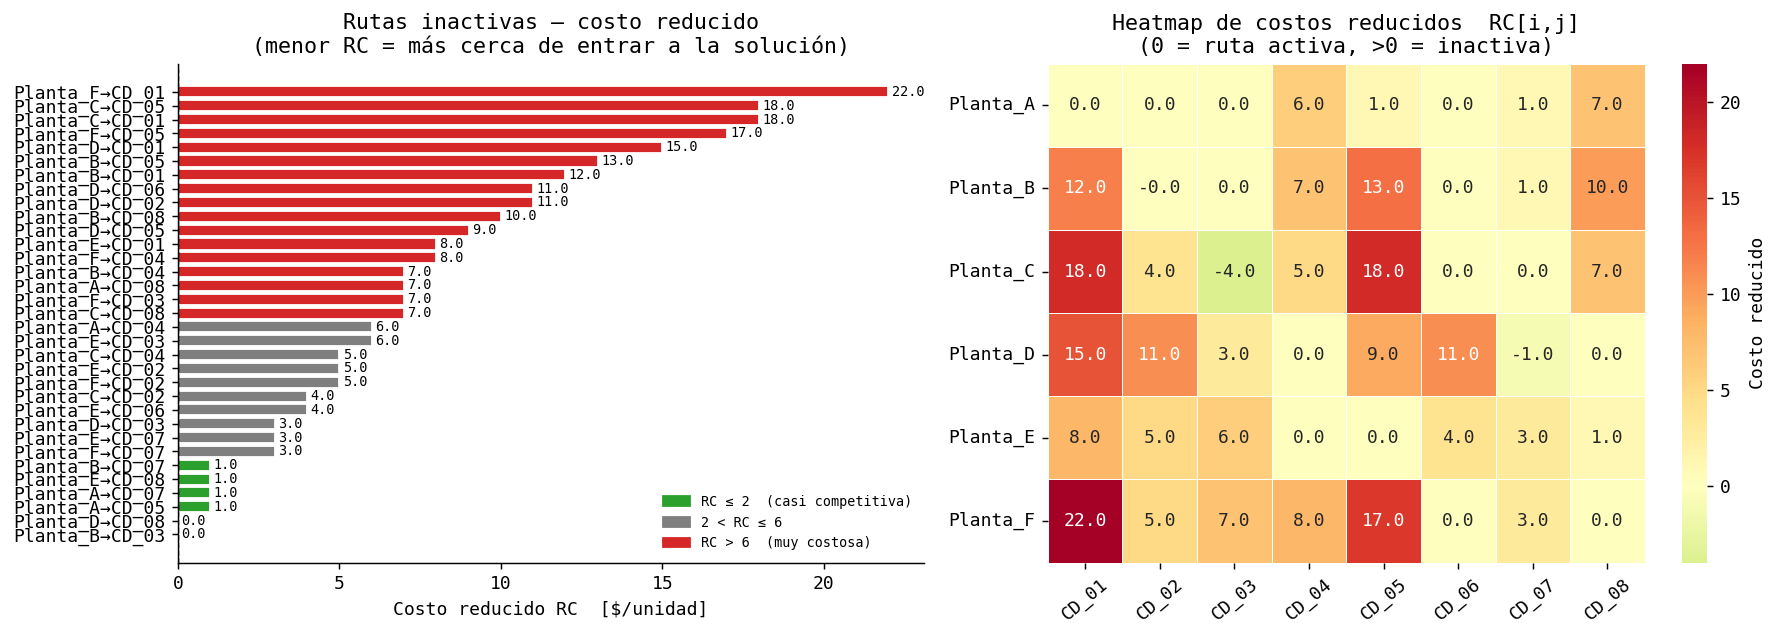

In [12]:
df_inactivas = df_v[~df_v["Activa"]].sort_values("RC")
df_activas   = df_v[ df_v["Activa"]].sort_values("RC")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Rutas inactivas: costo reducido (qué tan lejos están de entrar) ---
rc_vals  = df_inactivas["RC"].values
rc_rutas = df_inactivas["Ruta"].values
bar_colors = [PALETTE["activo"] if rc <= 2 else (PALETTE["neutro"] if rc <= 6 else PALETTE["inactivo"])
              for rc in rc_vals]
bars = axes[0].barh(rc_rutas, rc_vals, color=bar_colors, edgecolor="white")
axes[0].axvline(0, color="black", lw=0.8, ls="--")
axes[0].set_xlabel("Costo reducido RC  [$/unidad]")
axes[0].set_title("Rutas inactivas — costo reducido\n(menor RC = más cerca de entrar a la solución)")
for bar, val in zip(bars, rc_vals):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}", va="center", fontsize=7.5)

p_near = mpatches.Patch(color=PALETTE["activo"],   label="RC ≤ 2  (casi competitiva)")
p_mid  = mpatches.Patch(color=PALETTE["neutro"],   label="2 < RC ≤ 6")
p_far  = mpatches.Patch(color=PALETTE["inactivo"], label="RC > 6  (muy costosa)")
axes[0].legend(handles=[p_near, p_mid, p_far], frameon=False, fontsize=7.5)

# --- Heatmap de costo reducido (todas las rutas) ---
rc_matrix = np.array([[X[i, j].RC for j in J] for i in I])
sns.heatmap(rc_matrix, ax=axes[1], annot=True, fmt=".1f",
            cmap="RdYlGn_r", center=0,
            xticklabels=J, yticklabels=I, linewidths=0.5,
            cbar_kws={"label": "Costo reducido"})
axes[1].set_title("Heatmap de costos reducidos  RC[i,j]\n(0 = ruta activa, >0 = inactiva)")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()

### 7b — Rango de costo: ¿cuánto puede variar c[i,j] sin cambiar la solución?

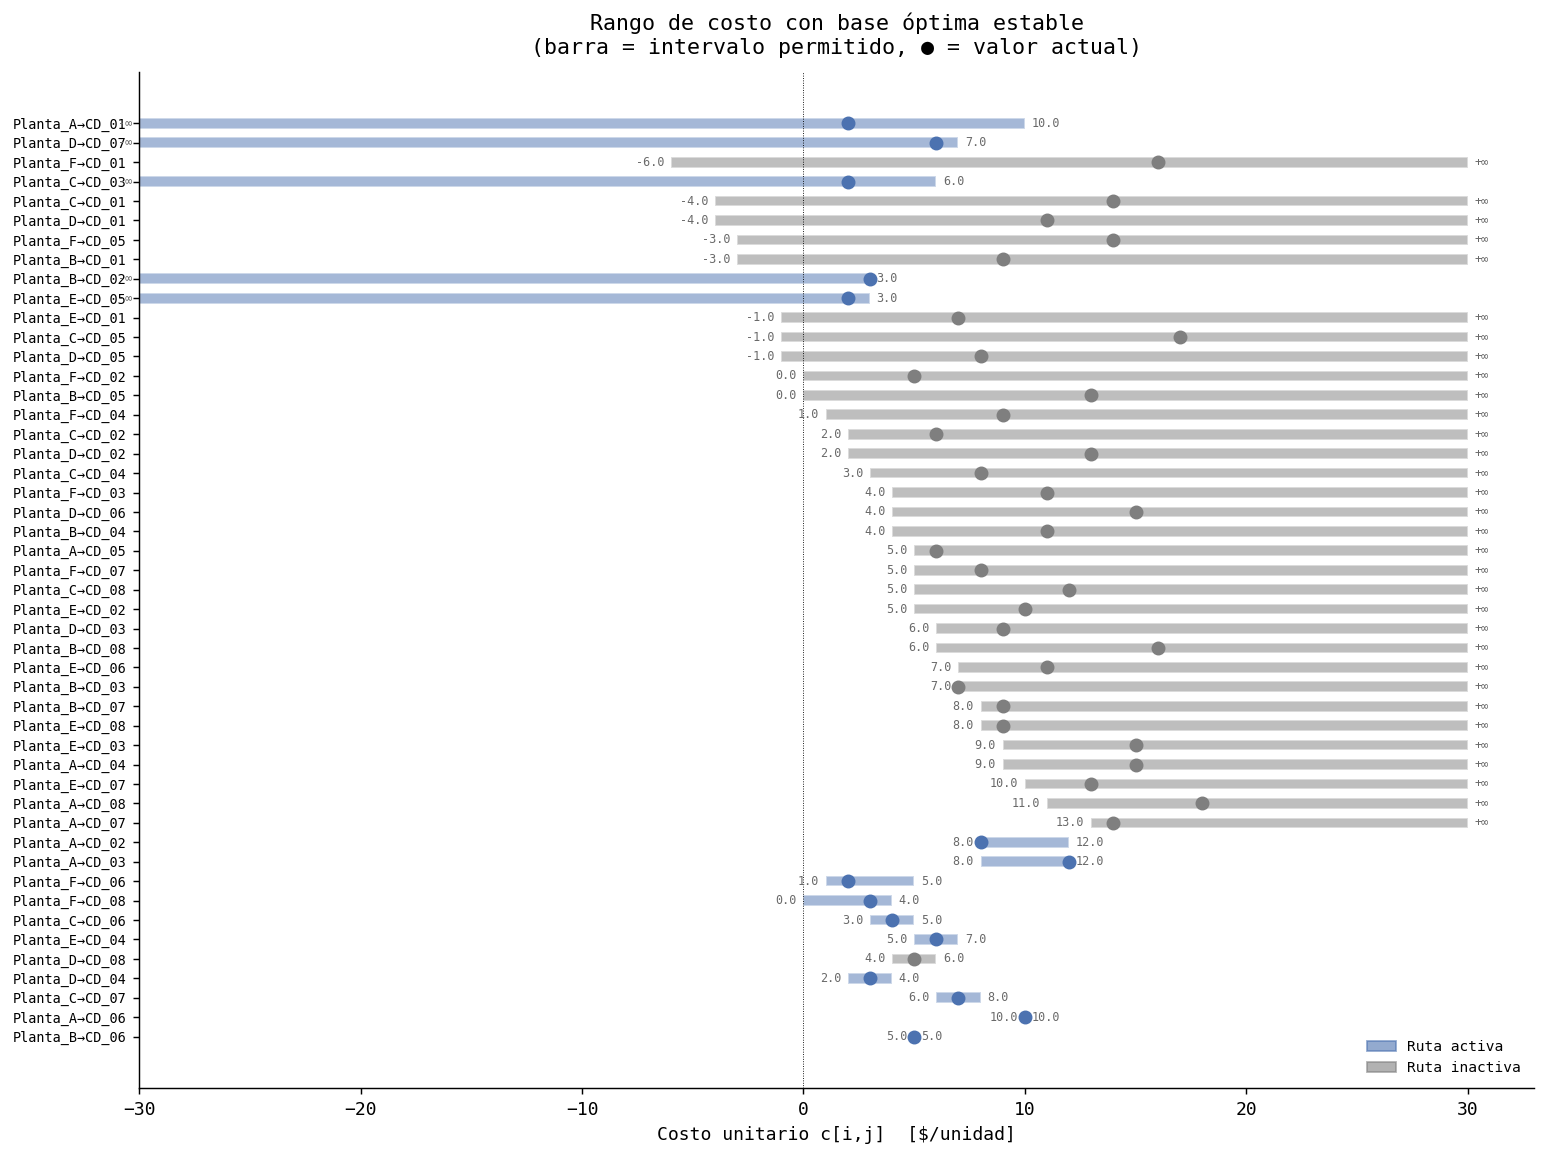

In [13]:
INF_C = 30
df_rng = df_v.copy()
df_rng["c_low_c"] = df_rng["c_low"].clip(lower=-INF_C)
df_rng["c_up_c"]  = df_rng["c_up"].clip(upper=INF_C)
df_rng["ancho"]   = df_rng["c_up_c"] - df_rng["c_low_c"]
df_rng = df_rng.sort_values("ancho")  # más sensibles arriba

fig, ax = plt.subplots(figsize=(12, 9))
y_pos = np.arange(len(df_rng))
act   = df_rng["Activa"].values

for idx, (_, row) in enumerate(df_rng.iterrows()):
    color = PALETTE["planta"] if row["Activa"] else PALETTE["neutro"]
    lo, hi, cur = row["c_low_c"], row["c_up_c"], row["c[i,j]"]
    # Barra de rango
    ax.barh(idx, hi - lo, left=lo, height=0.55, color=color, alpha=0.5, edgecolor="white")
    # Punto del costo actual
    ax.scatter(cur, idx, color=color, zorder=5, s=45)
    # Etiquetas de extremos
    lbl_lo = f"{row['c_low']:.1f}" if row["c_low"] > -INF_C else "-∞"
    lbl_hi = f"{row['c_up']:.1f}"  if row["c_up"]  <  INF_C else "+∞"
    ax.text(lo - 0.3, idx, lbl_lo, va="center", ha="right", fontsize=6.5, color="dimgray")
    ax.text(hi + 0.3, idx, lbl_hi, va="center", ha="left",  fontsize=6.5, color="dimgray")

ax.set_yticks(y_pos)
ax.set_yticklabels(df_rng["Ruta"], fontsize=7.5)
ax.set_xlabel("Costo unitario c[i,j]  [$/unidad]")
ax.set_title("Rango de costo con base óptima estable\n(barra = intervalo permitido, ● = valor actual)", pad=10)
ax.axvline(0, color="black", lw=0.5, ls=":")

p_act = mpatches.Patch(color=PALETTE["planta"], alpha=0.6, label="Ruta activa")
p_ina = mpatches.Patch(color=PALETTE["neutro"], alpha=0.6, label="Ruta inactiva")
ax.legend(handles=[p_act, p_ina], frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()